In [3]:
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.linear_model import LinearRegression


plt.style.use("seaborn-v0_8-muted")
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["figure.dpi"] = 100

# Get the default color palette
color1 = "#56b4e9"
color2 = "#e69f00"

color3 = "#009e73"
color4 = "#d55e00"

# The the style of the plots
plt.style.use('seaborn-v0_8-pastel')
# Remove the upper and right spines
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Set default figure DPI
plt.rcParams['figure.dpi'] = 300


Mean Sigma:
 [[462.6        432.6       ]
 [432.6        617.25749917]]
Mean mu_der:
 [1. 1.]


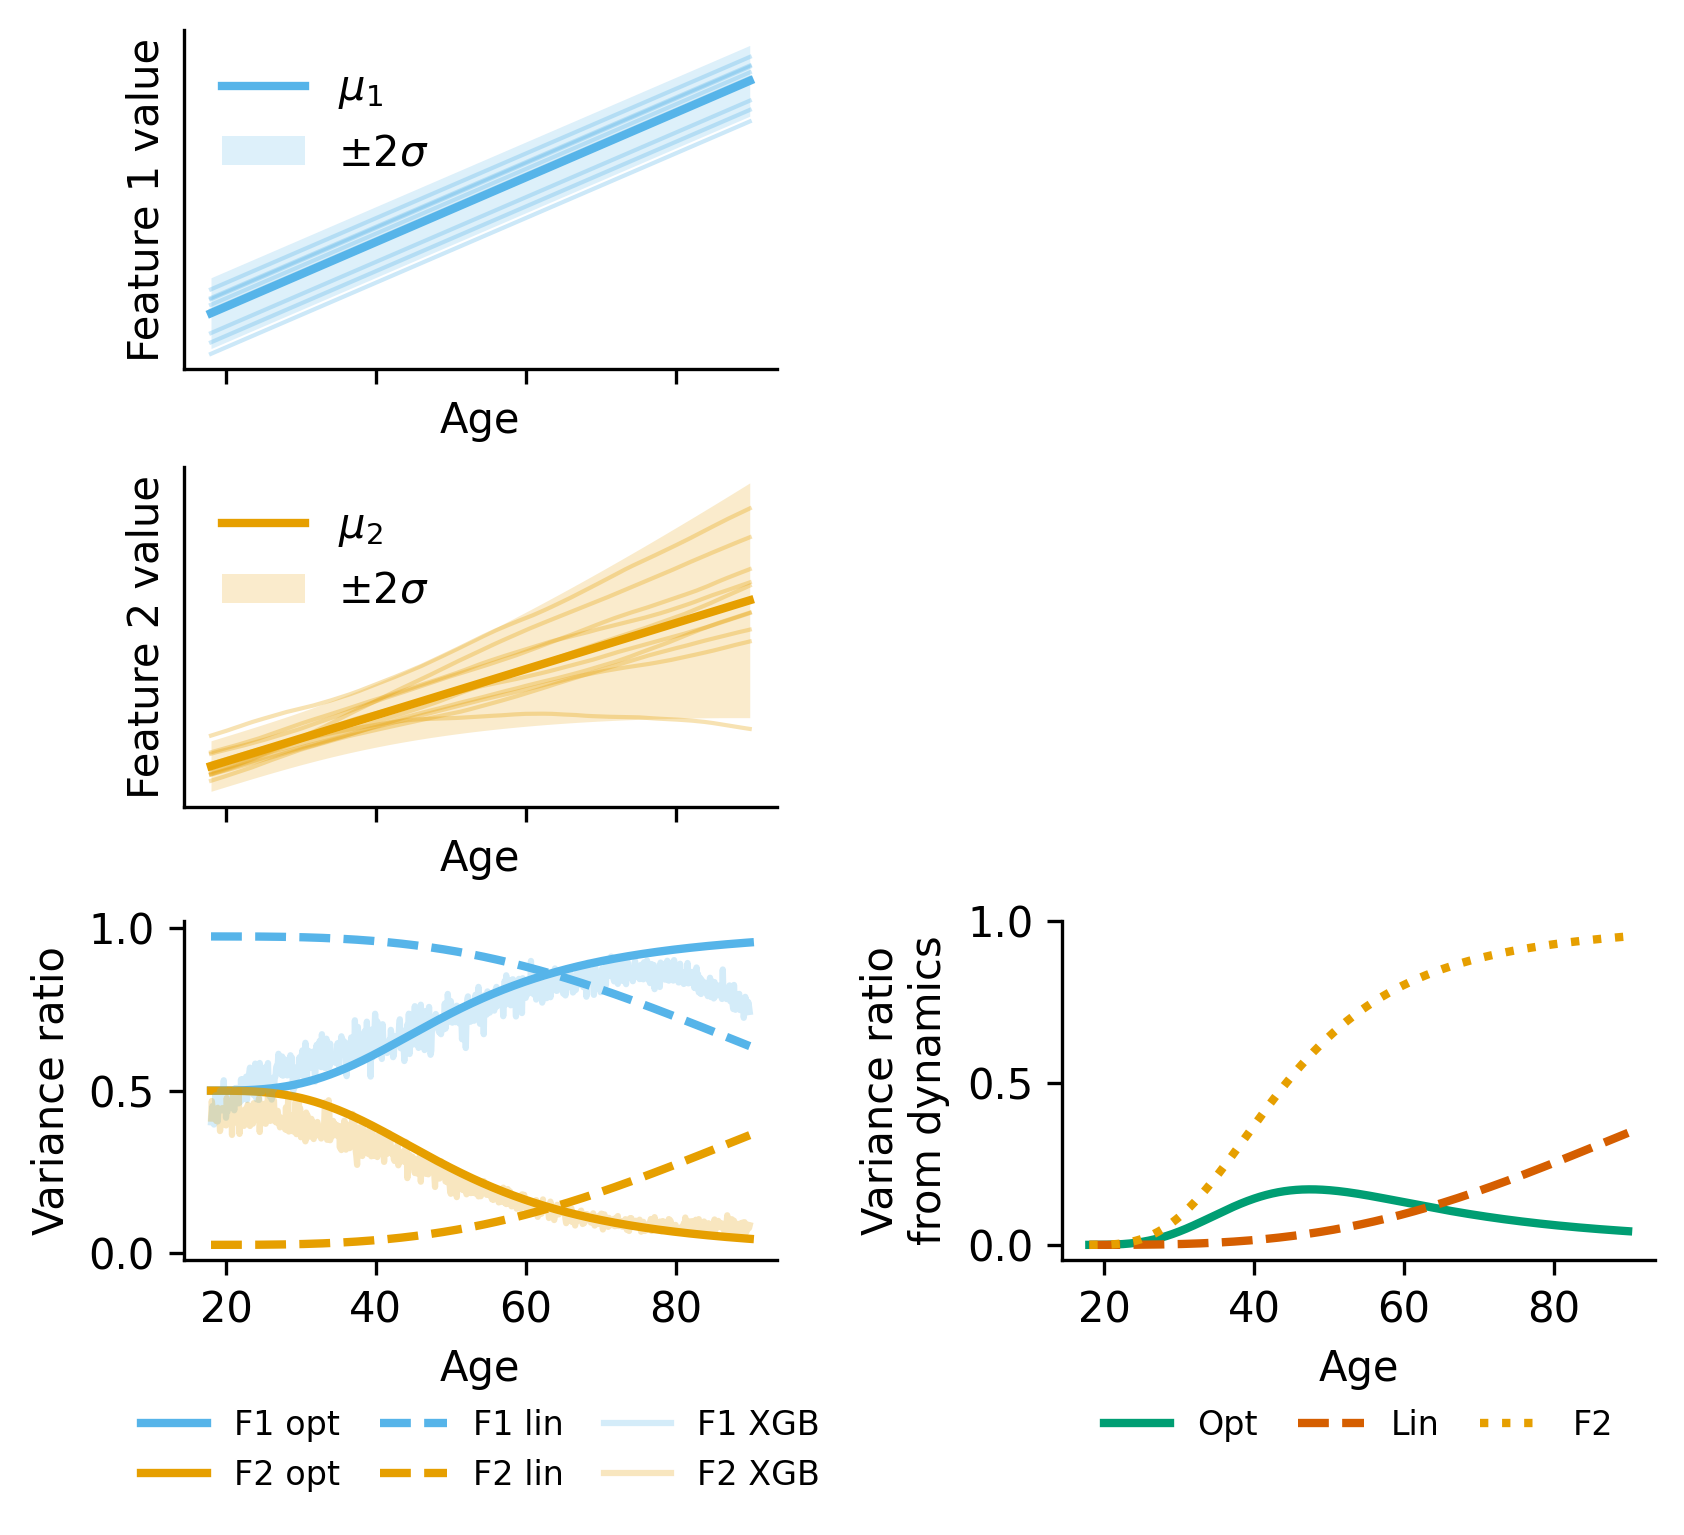

In [ ]:
def legend_inside(ax, loc="upper left"):
    """Legend inside the axes, no title, no border."""
    return ax.legend(loc=loc, frameon=False)


def legend_below_horizontal(ax, ncol=2, yoffset=-0.28, fontsize=10):
    """Horizontal legend below the axes, no border."""
    handles, labels = ax.get_legend_handles_labels()
    return ax.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, yoffset),
        ncol=ncol,
        frameon=False,
        handlelength=2.0,
        columnspacing=1.2,
        fontsize=fontsize,
    )


# -----------------------------
# Dynamical system
# -----------------------------
dt = 0.1
t = np.arange(18, 90, dt)

F = np.array(
    [
        [1, 0, dt, 0],
        [0, 1, 0, dt],
        [0, 0, 1, 0],
        [0, 0, 0, 1],
    ]
)

Q = np.array(
    [
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0.005], # Change this to see how different spread affects the results
    ]
)

# Initial state: mean and covariance
mu_0 = np.array([0, 0, 1.0, 1.0]) # Change this to see how different initial conditions affect the results
Sigma_0 = np.diag([30.0, 30.0, 0.0, 0.0])

z_mu = np.zeros((len(t), 4))
z_mu[0] = mu_0

z_Sigma = np.zeros((len(t), 4, 4))
z_Sigma[0] = Sigma_0

# Covariance accumulated from process noise only
z_Sigma_Q = np.zeros((len(t), 4, 4))

# -----------------------------
# Simulate sample trajectories
# -----------------------------
n_samples = 10
np.random.seed(8)

x_trajectories = np.zeros((n_samples, len(t), 4))
x_trajectories[:, 0, :] = np.random.multivariate_normal(mu_0, Sigma_0, size=n_samples)

for i in range(1, len(t)):
    z_mu[i] = F @ z_mu[i - 1] 
    z_Sigma[i] = F @ z_Sigma[i - 1] @ F.T + Q * dt
    z_Sigma_Q[i] = F @ z_Sigma_Q[i - 1] @ F.T + Q * dt

    for j in range(n_samples):
        process_noise = np.random.multivariate_normal(np.zeros(4), Q * dt)
        x_trajectories[j, i] = F @ x_trajectories[j, i - 1] + process_noise


# -----------------------------
# Derived quantities
# -----------------------------
mu_der = z_mu[:, 2:]                # "Derivative" states (2D)
Sigma_pos = z_Sigma[:, :2, :2]      # Position covariance (2x2 over time)

Sigma_pos_inv = np.linalg.inv(Sigma_pos)
den = np.einsum("ti, tij, tj->t", mu_der, Sigma_pos_inv, mu_der)
betas = np.einsum("tij, tj->ti", Sigma_pos_inv, mu_der) / den[:, np.newaxis]

mean_sigma = np.mean(Sigma_pos, axis=0) + np.cov(z_mu[:, :2], rowvar=False)
mean_mu_der = np.mean(mu_der, axis=0)

print("Mean Sigma:\n", mean_sigma)
print("Mean mu_der:\n", mean_mu_der)

betas_lin = np.linalg.inv(mean_sigma) @ mean_mu_der
betas_lin = betas_lin / (mean_mu_der @ np.linalg.inv(mean_sigma) @ mean_mu_der)

var_brain_age = 1.0 / den
var_brain_age_linear = betas_lin @ Sigma_pos @ betas_lin.T

var_brain_age_dyn = np.einsum("ti, tij, tj->t", betas, z_Sigma_Q[:, :2, :2], betas)
var_brain_age_linear_dyn = betas_lin @ z_Sigma_Q[:, :2, :2] @ betas_lin.T

# Compute the variance from each feature to the brain age (we can do this because the features are uncorrelated in this simulation)
betas_contribution = betas**2 * np.einsum("tii->ti", z_Sigma[:, :2, :2]) 
betas_lin_contribution = betas_lin**2 * np.einsum("tii->ti", z_Sigma[:, :2, :2])

# =========================================================
# Single figure using subplots (no subfigures)
# =========================================================
fig, axs = plt.subplots(
    3, 2,
    figsize=(5.5, 5),
    constrained_layout=True,
    sharex="col"  # share x within each column
)

ax_f1, ax_f2 = axs[0, 0], axs[1, 0]
ax_beta, ax_ratio = axs[2, 0], axs[2, 1]

ax_empty1, ax_empty2 = axs[0, 1], axs[1, 1]
for ax in [ax_empty1, ax_empty2]:
    ax.axis("off")

# --- Top-left: Feature 1 trajectories
ax_f1.plot(t, z_mu[:, 0], label=r"$\mu_1$", color=color1, lw=2)
ax_f1.fill_between(
    t,
    z_mu[:, 0] - 2 * np.sqrt(z_Sigma[:, 0, 0]),
    z_mu[:, 0] + 2 * np.sqrt(z_Sigma[:, 0, 0]),
    color=color1,
    alpha=0.2,
    lw=0,
    label=r"$\pm 2\sigma$",
)
for j in range(n_samples):
    ax_f1.plot(t, x_trajectories[j, :, 0], color=color1, alpha=0.3, lw=1)

ax_f1.set_xlabel("Age")
ax_f1.set_ylabel("Feature 1 value")
ax_f1.set_yticks([])
legend_inside(ax_f1, loc="upper left")

# --- Top-right: Feature 2 trajectories
ax_f2.plot(t, z_mu[:, 1], label=r"$\mu_2$", color=color2, lw=2)
ax_f2.fill_between(
    t,
    z_mu[:, 1] - 2 * np.sqrt(z_Sigma[:, 1, 1]),
    z_mu[:, 1] + 2 * np.sqrt(z_Sigma[:, 1, 1]),
    color=color2,
    alpha=0.2,
    lw=0,
    label=r"$\pm 2\sigma$",
)
for j in range(n_samples):
    ax_f2.plot(t, x_trajectories[j, :, 1], color=color2, alpha=0.3, lw=1)

ax_f2.set_xlabel("Age")
ax_f2.set_ylabel("Feature 2 value")
ax_f2.set_yticks([])

legend_inside(ax_f2, loc="upper left")

# --- Bottom-left: Betas vs age
ax_beta.plot(t, betas_contribution[:, 0] / var_brain_age, label="F1 opt", color=color1, lw=2)
ax_beta.plot(t, betas_contribution[:, 1] / var_brain_age, label="F2 opt", color=color2, lw=2)
ax_beta.plot(t, betas_lin_contribution[:, 0] / var_brain_age_linear, label="F1 lin", color=color1, linestyle="dashed", lw=2)
ax_beta.plot(t, betas_lin_contribution[:, 1] / var_brain_age_linear, label="F2 lin", color=color2, linestyle="dashed", lw=2)

ax_beta.set_xlabel("Age")
ax_beta.set_ylabel("Variance ratio")

# --- Bottom-right: Variance ratios
ax_ratio.plot(t, var_brain_age_dyn / var_brain_age, label="Opt", lw=2, color=color3)
ax_ratio.plot(
    t,
    var_brain_age_linear_dyn / var_brain_age_linear,
    label="Lin",
    lw=2,
    color=color4,
    linestyle="dashed",
)
ax_ratio.plot(
    t,
    z_Sigma_Q[:, 1, 1] / z_Sigma[:, 1, 1],
    label="F2",
    lw=2,
    color=color2,
    linestyle="dotted",
)

ax_ratio.set_xlabel("Age")
ax_ratio.set_ylabel("Variance ratio\nfrom dynamics")

use_xgboost = True
if use_xgboost:
    # Sample n samples from each age to create a dataset
    n_sim_samples = 500
    data = np.zeros((n_sim_samples, len(t), 4))
    data_age = np.tile(t, (n_sim_samples, 1))
    data_test = np.zeros((n_sim_samples, len(t), 4))
    data_test_age = np.tile(t, (n_sim_samples, 1))
    
    np.random.seed(42)
    for i in range(len(t)):
        data[:, i, :] = np.random.multivariate_normal(z_mu[i], z_Sigma[i], size=n_sim_samples)
        data_test[:, i, :] = np.random.multivariate_normal(z_mu[i], z_Sigma[i], size=n_sim_samples)
        
    data_age = data_age.flatten()
    data_features = data[:, :, :2].reshape(n_sim_samples * len(t), 2)
    
    data_test_age = data_test_age.flatten()
    data_test_features = data_test[:, :, :2].reshape(n_sim_samples * len(t), 2)
    
    # Train an XGBoost model to predict age from features
    dtrain = xgb.DMatrix(data_features, label=data_age)
    dtest = xgb.DMatrix(data_test_features, label=data_test_age)
    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
    }
    num_boost_round = 100
    bst = xgb.train(params, dtrain, num_boost_round)

    # Evaluate the model on the test data
    preds = bst.predict(dtest)
    
    preds_age = preds.reshape(n_sim_samples, len(t))
    # For each age use linear regression to get local linear sensitivity
    local_linear_sensitivity = np.zeros((len(t), 2))
    for i in range(len(t)):
        lr = LinearRegression()
        X_age = data_test[:, i, :2]
        y_age = preds_age[:, i]
        lr.fit(X_age, y_age)
        local_linear_sensitivity[i, :] = (lr.coef_ * np.std(X_age, axis=0) / np.std(y_age))**2
        
    # Plot the local linear sensitivity over age
    ax_beta.plot(t, local_linear_sensitivity[:, 0], label="F1 XGB", color=color1, alpha=0.25)
    ax_beta.plot(t, local_linear_sensitivity[:, 1], label="F2 XGB", color=color2, alpha=0.25)
    ax_beta.set_xlabel("Age")

legend_below_horizontal(ax_beta, ncol=3, yoffset=-0.35, fontsize=8)
legend_below_horizontal(ax_ratio, ncol=3, yoffset=-0.35, fontsize=8)

plt.show()
# Save as svg
fig.savefig("dynamic_brain_age_figure.svg", format="svg")